## Evaluate Modular NN per Drainage Basin

Tables 3 & C1, Figure 6

run calc_climatology.ipynb beforehand!

In [14]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2

fig_dir = os.path.sep.join([base_dir, 'figures'])

MODE = 'test'  # use test set!

In [ ]:
# load daily melt predictions
chunking = {'time': -1, 'y': -1, 'x': -1}
pred_dir = os.path.sep.join([base_dir, 'output', 'modularNN'])
ds_pred = xr.open_dataset(os.path.sep.join([pred_dir, 'pred_data_1990-2016.zarr'])).chunk(chunking)

# load climatology of true melt
ds_clim = xr.load_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_snmel_1990-2013_smoothed15.nc']))
snmel_clim = ds_clim['snmel'].sel(x=ds_pred['x'], y=ds_pred['y'])

# load climatology of predicted melt
pred_dir = os.path.sep.join([base_dir, 'output', 'modularNN'])
snmel_clim_pred = xr.open_zarr(os.path.sep.join([pred_dir, 'pred_climat_1990-2013_15dayrolling.zarr']))['snmel_pred']

/tmp/squashed-elkesc-store/store/miniforge3/envs/env_FirnML/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [4]:
# load basins
data_dir = os.path.sep.join([base_dir, 'data', 'processed', 'HIRHAM5-ERAInterim', 'v_02'])
ds_basins = xr.open_dataset(data_dir + '/GRLmask.zarr').set_index(z=['y', 'x']).unstack('z')['maskbas']

basins = {   1: 'N',
            2: 'NE',
            3: 'CE',
             4: 'SE',
             5: 'SW',
             6: 'NW' }

In [5]:
# predict anomalies for 2016 w.r.t. climatology 1990-2013

pred_da = ds_pred['snmel_pred'].sel(time=slice('2016-01-01','2016-12-31')).compute()
true_da = ds_pred['snmel_true'].sel(time=slice('2016-01-01','2016-12-31')).compute()
ds_clim = ds_clim.sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int))

def calc_anomaly(ds, clim):
    md_clim = clim['time'].dt.strftime('%m-%d')        # DataArray of strings length 366
    clim = clim.assign_coords(md=md_clim)              # attach md coordinate to the DataArray

    # 2. group by the md coordinate and average (should give one value per md per spatial point)
    clim = clim.groupby('md').mean(dim='time')   # dims: ('md', spatial...)

    # 3. prepare the main data: build md for every day; map 02-29 -> 02-28 if desired
    # da = ds_melt.set_index(z=['y', 'x']).unstack('z').transpose('time', 'y', 'x')

    md_data = ds['time'].dt.strftime('%m-%d')
    #md_data_fixed = md_data.where(md_data != '02-29', other='02-28')  # simple leap-day treatment
    ds = ds.assign_coords(md=('time', md_data.values))         # attach md coord to data

    # 4. subtract: groupby on md aligns with clim_by_md's md coordinate; broadcasting happens automatically
    anomaly = (ds.groupby('md') - clim).compute()

    return anomaly


anomaly_pred = calc_anomaly(pred_da, ds_clim['snmel'])
anomaly_true = calc_anomaly(true_da, ds_clim['snmel'])

## Basin-wise Scores of Modular NN

In [8]:
# Tables 3 and C1: Basin-wise scores for whole period and for 2016 only
# this takes a few minutes ...

time_periods = [('1990-01-01', '2016-12-31'), ('2016-01-01' ,'2016-12-31')]

for start_date, end_date in time_periods:
    print(f'Calculate scores per basin for period {start_date} to {end_date}')
    pred_da = ds_pred['snmel_pred'].sel(time=slice(start_date, end_date)).compute()
    true_da = ds_pred['snmel_true'].sel(time=slice(start_date, end_date)).compute()

    df = pd.DataFrame(columns=['mean melt', 'RMSE', 'NRMSE', 'MAE', 'NMAE', 'MBE', 'R2', 'R2_anomalies', 'MAE/RMSE'], index=basins.values(), dtype=float)
    df.index.name = 'basin'

    residual = pred_da - true_da
    annual_sums = true_da.groupby("time.year").sum(dim="time")
    mean_melt = annual_sums.mean().item()
    df.loc['GrIS', 'mean melt'] = mean_melt
    df.loc['GrIS', 'RMSE'] = get_rmse(residual)
    df.loc['GrIS', 'NRMSE'] = df.loc['GrIS', 'RMSE']/mean_melt*100
    df.loc['GrIS', 'MAE'] = get_mae(residual)
    df.loc['GrIS', 'NMAE'] = df.loc['GrIS', 'MAE']/mean_melt*100
    df.loc['GrIS', 'MBE'] = get_mbe(residual)
    df.loc['GrIS', 'R2'] = get_r2(true_da.values, pred_da.values)
    df.loc['GrIS', 'R2_anomalies'] = get_r2(anomaly_true.values, anomaly_pred.values)
    df.loc['GrIS', 'MAE/RMSE'] = df.loc['GrIS', 'MAE']/df.loc['GrIS', 'RMSE']

    for i,z in basins.items():
        print(f'Process basin {z}')
        pred_da_zone = pred_da.where(ds_basins==i, drop=True)
        true_da_zone = true_da.where(ds_basins==i, drop=True)
        annual_sums = true_da_zone.groupby("time.year").sum(dim="time")
        mean_melt = annual_sums.mean().item()
        residual = pred_da_zone - true_da_zone
        df.loc[z, 'mean melt'] = mean_melt
        df.loc[z, 'RMSE'] = get_rmse(residual)
        df.loc[z, 'NRMSE'] = df.loc[z, 'RMSE']/mean_melt*100
        df.loc[z, 'MAE'] = get_mae(residual)
        df.loc[z, 'NMAE'] = df.loc[z, 'MAE']/mean_melt*100
        df.loc[z, 'MBE'] = get_mbe(residual)
        df.loc[z, 'MAE/RMSE'] = df.loc[z, 'MAE']/df.loc[z, 'RMSE']

        anomaly_pred_da_zone = anomaly_pred.where(ds_basins==i, drop=True)
        anomaly_true_da_zone = anomaly_true.where(ds_basins==i, drop=True)

        df.loc[z, 'R2'] = get_r2(true_da_zone.values, pred_da_zone.values)
        df.loc[z, 'R2_anomalies'] = get_r2(anomaly_true_da_zone.values, anomaly_pred_da_zone.values)

    display(df.round(2))

Calculate scores per basin for period 1990-01-01 to 2016-12-31
Process basin N
Process basin NE
Process basin CE
Process basin SE
Process basin SW
Process basin NW


,mean melt,RMSE,NRMSE,MAE,NMAE,MBE,R2,R2_anomalies,MAE/RMSE
basin,,,,,,,,,
N,122.29,1.03,0.84,0.18,0.15,-0.01,0.95,0.79,0.18
NE,136.61,0.85,0.62,0.13,0.09,-0.01,0.95,0.82,0.15
CE,138.75,0.78,0.56,0.14,0.10,0.01,0.95,0.79,0.17
SE,159.66,0.84,0.53,0.20,0.12,-0.01,0.98,0.90,0.23
SW,186.29,0.80,0.43,0.16,0.09,-0.02,0.98,0.87,0.20
NW,146.32,0.72,0.49,0.11,0.08,-0.01,0.97,0.80,0.16
GrIS,158.66,0.83,0.53,0.15,0.09,-0.01,0.97,0.85,0.18


Calculate scores per basin for period 2016-01-01 to 2016-12-31
Process basin N
Process basin NE
Process basin CE
Process basin SE
Process basin SW
Process basin NW


,mean melt,RMSE,NRMSE,MAE,NMAE,MBE,R2,R2_anomalies,MAE/RMSE
basin,,,,,,,,,
N,142.65,0.97,0.68,0.18,0.13,0.06,0.96,0.79,0.19
NE,174.10,0.77,0.44,0.13,0.08,0.01,0.97,0.82,0.17
CE,158.84,0.82,0.52,0.15,0.10,-0.01,0.95,0.79,0.19
SE,177.05,0.97,0.55,0.23,0.13,-0.03,0.97,0.90,0.24
SW,221.39,1.02,0.46,0.22,0.10,-0.09,0.97,0.87,0.22
NW,159.28,0.83,0.52,0.14,0.09,0.04,0.96,0.80,0.17
GrIS,185.46,0.90,0.48,0.18,0.09,-0.01,0.97,0.85,0.20


## Temporal distribution of over- and underestimations of Modular NN per basin

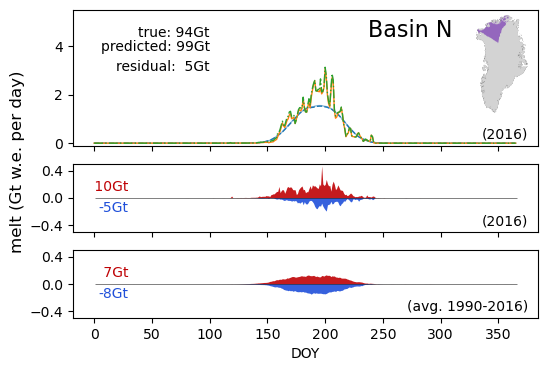

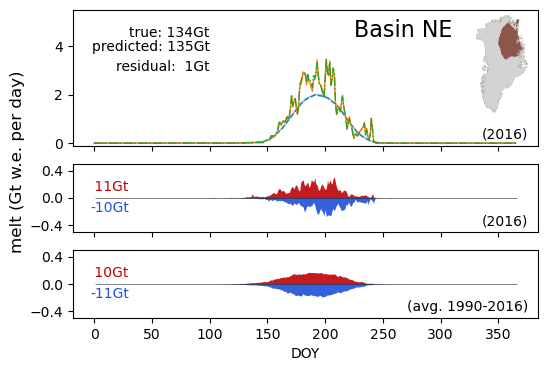

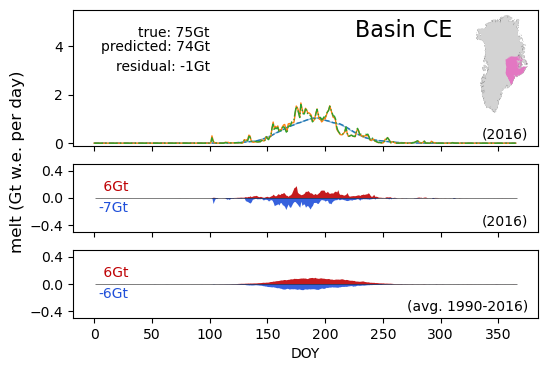

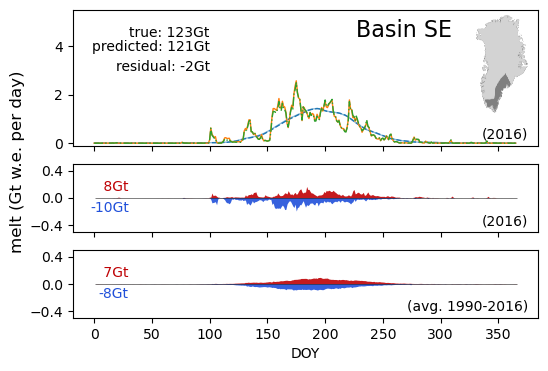

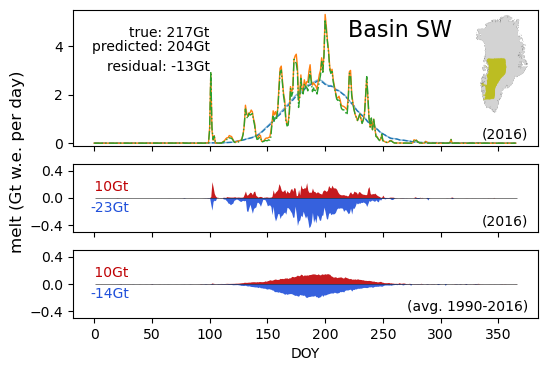

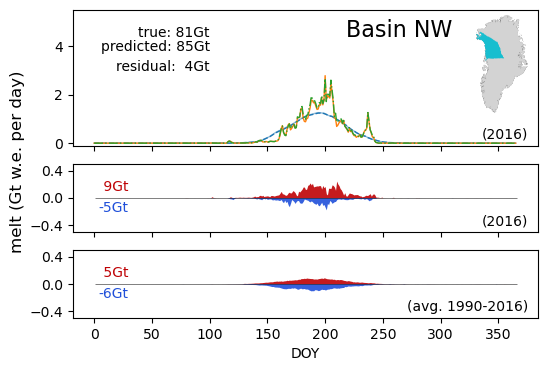

In [15]:
# Figure 6
# this takes a few minutes ...

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scaling_factor = 1.796553703424 / 58391    # from mm w.e. to Gt
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = [mcolors.to_hex(c) for c in cmap.colors[:3]]
cmap_rb = mcolors.ListedColormap(cc.CET_D1)
blue = cmap_rb.colors[0]
red = cmap_rb.colors[-1]

fig_dir = os.path.sep.join([base_dir, 'figures'])

pred_da = ds_pred['snmel_pred'].sel(time=slice('1990-01-01','2016-12-31'))
true_da = ds_pred['snmel_true'].sel(time=slice('1990-01-01','2016-12-31'))
n_years = len(np.unique(true_da['time.year']))

for i,z in basins.items():
    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(6,4), sharex=True, height_ratios=[2,1,1])

    # plot melt of 2016
    pred_da_zone = pred_da.where(ds_basins==i).sel(time=slice('2016-01-01','2016-12-31'))
    true_da_zone = true_da.where(ds_basins==i).sel(time=slice('2016-01-01','2016-12-31'))
    true_da_zone_total = true_da_zone.sum(dim=['x', 'y']).compute()*scaling_factor
    pred_da_zone_total = pred_da_zone.sum(dim=['x', 'y']).compute()*scaling_factor
    ax0.plot(snmel_clim.where(ds_basins==i).sum(dim=['x', 'y'])*scaling_factor, linewidth=1, label='climatology true', color=colors[0], alpha=0.5)
    ax0.plot(snmel_clim_pred.where(ds_basins==i).sum(dim=['x', 'y'])*scaling_factor, linewidth=1, label='climatology predicted', color=colors[0], linestyle='--')
    ax0.plot(true_da_zone_total, linewidth=1, label=f'true melt', color=colors[1])
    ax0.plot(pred_da_zone_total, linewidth=1, linestyle='-.', label=f'predicted melt', color=colors[2])
    
    ax0.set_ylim(-0.1,5.5)
    ax0.text(376, 0.2, '(2016)', ha='right')
    total_true = true_da_zone_total.sum().item()
    total_pred = pred_da_zone_total.sum().item()
    ax0.text(100, 4.4, f'true: {int(round(total_true)):2d}Gt', ha='right')
    ax0.text(100, 3.8, f'predicted: {int(round(total_pred)):2d}Gt', ha='right')
    ax0.text(100, 3., f'residual: {int(round(total_pred-total_true)):2d}Gt', ha='right')

    basin_img = plt.imread(os.path.sep.join([fig_dir, f'basin_{i}.png']))
    axins = inset_axes(ax0, width="15%", height="80%", loc='upper right', borderpad=0)
    axins.imshow(basin_img)
    axins.axis('off')
    ax0.text(310, 4.4, f'Basin {z}', ha='right', fontsize=16)
        
    # plot residuals of 2016
    residual = pred_da_zone - true_da_zone
    over_t = residual.where(residual>0).sum(dim=['x', 'y']).compute()*scaling_factor
    under_t = residual.where(residual<0).sum(dim=['x', 'y']).compute()*scaling_factor
    ax1.hlines(y=0, xmin=1, xmax=366, color='k', linewidth=0.5, alpha=0.7)
    ax1.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, over_t, label='overestimation', color=red, alpha=0.9, linewidth=0.)
    ax1.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, under_t, label='underestimation', color=blue, alpha=0.9, linewidth=0.)

    ax1.set_ylim(-.5,.5)
    ax1.set_yticks([-0.4, 0, 0.4])
    ax1.text(376, -0.4, '(2016)', ha='right')
    ax1.text(30, 0.1, f' {int(round(over_t.sum().item()))}Gt', color=red, ha='right')
    ax1.text(30, -0.2, f'{int(round(under_t.sum().item()))}Gt', color=blue, ha='right')

    # plot residuals averaged over 1990-2016
    pred_da_zone = pred_da.where(ds_basins==i).sel(time=slice('1990-01-01','2016-12-31'))
    true_da_zone = true_da.where(ds_basins==i).sel(time=slice('1990-01-01','2016-12-31'))
    residual = pred_da_zone - true_da_zone
    over_t = residual.where(residual>0).sum(dim=['x', 'y']).compute()*scaling_factor
    under_t = residual.where(residual<0).sum(dim=['x', 'y']).compute()*scaling_factor
    over_t = over_t.groupby('time.dayofyear').mean(dim='time')
    under_t = under_t.groupby('time.dayofyear').mean(dim='time')
    ax2.hlines(y=0, xmin=1, xmax=366, color='k', linewidth=0.5, alpha=0.7)
    ax2.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, over_t, label='overestimation', color=red, alpha=0.9, linewidth=0.)
    ax2.fill_between(np.linspace(1,len(over_t),len(over_t)), 0, under_t, label='underestimation', color=blue, alpha=0.9, linewidth=0.)

    ax2.set_xlabel('DOY')
    ax2.set_ylim(-.5,.5)
    ax2.set_yticks([-0.4, 0, 0.4])
    ax2.text(376, -0.4, '(avg. 1990-2016)', ha='right')
    ax2.text(30, 0.1, f' {int(round(over_t.sum().item()))}Gt', color=red, ha='right')
    ax2.text(30, -0.2, f'{int(round(under_t.sum().item()))}Gt', color=blue, ha='right')
    
    fig.supylabel('melt (Gt w.e. per day)')

    fig.savefig(os.path.sep.join([fig_dir, f'modularNN_basin{z}.png']), bbox_inches='tight', dpi=300)
    plt.show()


# --- build and save legend as its own figure ---
handles, labels = ax0.get_legend_handles_labels()
fig_legend = plt.figure(figsize=(5, 1))
leg = fig_legend.legend(handles, labels, loc='center', frameon=False, ncol=4)
fig_legend.canvas.draw()

fig_legend.savefig(os.path.sep.join([fig_dir, "modularNN_basins_legend.png"]), bbox_inches='tight', dpi=200)
plt.close(fig_legend)